In [1]:
import sqlite3
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from datetime import datetime
from tqdm import tqdm
import time

## Phase 1: Introduction to SQL and Databases + Python Integration (Setup)
### Goal: Create the database, define all tables, and load data from CSVs.

In [2]:
# =============================================
# CLEAN RESTART CELL - Run this first to start fresh
# =============================================

# Step 1: Close any existing connection and delete old database
try:
    conn.close()
except:
    pass

if os.path.exists('database.db'):
    os.remove('database.db')
    print("✅ Old database.db deleted successfully!")
else:
    print("No existing database found. Starting fresh.")

✅ Old database.db deleted successfully!


In [3]:
# Step 2: Create a new clean connection
conn = sqlite3.connect('database.db')
print("✅ New clean database created.")

✅ New clean database created.


In [4]:
# conn (connection) = The pipe that connects your Python code to the database file.
# cursor = The pen you use to write SQL commands through that pipe.

In [5]:
# Step 3: Load the corrected schema
try:
    with open('schema.sql', 'r', encoding='utf-8') as f:
        schema_script = f.read()
    
    conn.executescript(schema_script)
    conn.commit()
    print("✅ Schema loaded successfully! All tables created.")
    
except Exception as e:
    print(f"❌ Error loading schema: {e}")

✅ Schema loaded successfully! All tables created.


In [6]:
# Step 4: Verify tables
print("\n📋 Tables created:")
tables_df = pd.read_sql("SELECT name AS table_name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
print(tables_df)


📋 Tables created:
               table_name
0        course_exam_info
1             course_info
2          course_ratings
3               quiz_info
4      student_engagement
5            student_exam
6   student_hub_questions
7            student_info
8        student_learning
9       student_purchases
10        student_quizzes


In [7]:
# =============================================
# FINAL ROBUST CSV LOADING CELL
# Loads ALL data even with orphan records
# =============================================

print("🚀 Starting ROBUST CSV loading (foreign keys temporarily disabled)...\n")

# Step 1: Disable foreign key checks so orphans don't block loading
conn.execute("PRAGMA foreign_keys = OFF;")
conn.commit()
print("✅ Foreign key checks DISABLED (allowing orphan records)")

# Step 2: Load tables in logical parent → child order
load_order = [
    'course_info',
    'student_info',
    'course_exam_info',
    'quiz_info',
    'student_purchases',
    'student_learning',
    'student_engagement',
    'student_quizzes',
    'student_exam',
    'course_ratings',
    'student_hub_questions'
]

csv_files = [f"{table}.csv" for table in load_order]

for csv_file in csv_files:
    table_name = csv_file.replace('.csv', '')
    file_path = f'data/{csv_file}'
    
    try:
        df = pd.read_csv(file_path)
        
        # Automatically drop any extra columns that don't exist in the table
        table_info = pd.read_sql(f"PRAGMA table_info({table_name});", conn)
        table_columns = table_info['name'].tolist()
        extra_cols = [col for col in df.columns if col not in table_columns]
        if extra_cols:
            print(f"   ⚠️  {csv_file}: ignoring extra columns → {extra_cols}")
            df = df.drop(columns=extra_cols)
        
        # Load the data
        df.to_sql(table_name, conn, if_exists='append', index=False)
        print(f"✅ Loaded {len(df):,} rows → {table_name}")
        
    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
    except Exception as e:
        print(f"❌ Failed to load {csv_file}: {e}")

# Step 3: Re-enable foreign key checks
conn.execute("PRAGMA foreign_keys = ON;")
conn.commit()
print("\n✅ Foreign key checks RE-ENABLED")

print("\n🎉 ALL DATA LOADING COMPLETE!")
print("You can now run analytics queries even with orphan records.")

# Optional: Show row counts for every table
print("\n📊 Final row counts:")
for table in load_order:
    try:
        count = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table}", conn).iloc[0,0]
        print(f"   {table:25} → {count:,} rows")
    except:
        print(f"   {table:25} → error checking count")

🚀 Starting ROBUST CSV loading (foreign keys temporarily disabled)...

✅ Foreign key checks DISABLED (allowing orphan records)
✅ Loaded 46 rows → course_info
✅ Loaded 1,000 rows → student_info
✅ Loaded 156 rows → course_exam_info
✅ Loaded 1,000 rows → quiz_info
✅ Loaded 1,000 rows → student_purchases
✅ Loaded 1,000 rows → student_learning
✅ Loaded 1,000 rows → student_engagement
❌ Failed to load student_quizzes.csv: Execution failed
✅ Loaded 1,000 rows → student_exam
✅ Loaded 1,000 rows → course_ratings
✅ Loaded 827 rows → student_hub_questions

✅ Foreign key checks RE-ENABLED

🎉 ALL DATA LOADING COMPLETE!
You can now run analytics queries even with orphan records.

📊 Final row counts:
   course_info               → 46 rows
   student_info              → 1,000 rows
   course_exam_info          → 156 rows
   quiz_info                 → 1,000 rows
   student_purchases         → 1,000 rows
   student_learning          → 1,000 rows
   student_engagement        → 1,000 rows
   student_quizze

- ON DELETE CASCADE mean is a rule you put on a Foreign Key that tells SQLite:
“If I delete a row from the parent table, automatically delete all related rows ie orphan records, in this child table.”
- ON DELETE RESTRICT     -- prevents deletion if related rows exist
- Disable foreign key checks so orphans don't block loading
conn.execute("PRAGMA foreign_keys = OFF;")

- student_quizzes table composite PRIMARY KEY
- PRIMARY KEY (student_id, quiz_id, question_id, answer_id)
This means no duplicate combinations of those 4 columns are allowed.
Your CSV likely has:

Duplicate rows (same student + quiz + question + answer answered multiple times), or
Extra columns that don't exist in the table, or
Null/empty values in one of the key columns.

%%sql
select sql from sqlite_master

In [8]:
# =============================================
# ULTRA-TOLERANT FIX FOR student_quizzes (Option C)
# =============================================

print("🔧 Applying ultra-tolerant fix for student_quizzes...\n")

# Drop the old table completely
conn.execute("DROP TABLE IF EXISTS student_quizzes;")
conn.commit()

# Create the simplest possible table
conn.execute("""
    CREATE TABLE student_quizzes (
        student_id     INTEGER,
        quiz_id        INTEGER,
        question_id    INTEGER,
        answer_id      INTEGER,
        attempt_date   TEXT,
        score          REAL,
        created_at     TEXT DEFAULT CURRENT_TIMESTAMP
    );
""")
conn.commit()
print("✅ Created ultra-simple student_quizzes table (no constraints)")

# Load the CSV with maximum tolerance
try:
    df = pd.read_csv('data/student_quizzes.csv')
    
    print(f"CSV loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
    print(f"CSV columns: {list(df.columns)}")
    
    # Keep only columns that make sense
    keep_cols = ['student_id', 'quiz_id', 'question_id', 'answer_id']
    if 'attempt_date' in df.columns:
        keep_cols.append('attempt_date')
    if 'score' in df.columns:
        keep_cols.append('score')
    
    df = df[keep_cols]
    
    # Remove exact duplicates
    original = len(df)
    df = df.drop_duplicates()
    if original > len(df):
        print(f"Removed {original - len(df):,} duplicate rows")
    
    # Load into database
    df.to_sql('student_quizzes', conn, if_exists='append', index=False)
    
    final_count = len(df)
    print(f"✅ Successfully loaded {final_count:,} rows into student_quizzes")
    
except Exception as e:
    print(f"❌ Error: {e}")

# Final check
try:
    count = pd.read_sql("SELECT COUNT(*) as count FROM student_quizzes", conn).iloc[0,0]
    print(f"\nFinal row count in student_quizzes: {count:,} rows")
except Exception as e:
    print(f"Could not count rows: {e}")

🔧 Applying ultra-tolerant fix for student_quizzes...

✅ Created ultra-simple student_quizzes table (no constraints)
CSV loaded: 1,000 rows, 4 columns
CSV columns: ['student_id', 'quiz_id', 'question_id', 'answer_id']
✅ Successfully loaded 1,000 rows into student_quizzes

Final row count in student_quizzes: 1,000 rows


In [9]:
count = pd.read_sql("SELECT COUNT(*) as row_count FROM student_quizzes", conn).iloc[0,0]
print(f"Final row count in student_quizzes: {count:,} rows")

Final row count in student_quizzes: 1,000 rows


Always double-check column names when writing SQL. You can check your exact column names anytime with
pd.read_sql("PRAGMA table_info(student_purchases);", conn)

**Demonstrates**: Database creation, schema design, Python + SQLite integration, bulk data import.

## Phase 2: Summarizing Data in SQL + Visualizations
### Goal: Compute key platform KPIs and identify high-level issues.

In [10]:
# -------------------------------------------------
# 1. Overall Platform KPIs
# -------------------------------------------------
print("📊 Starting Phase 2: Summarizing Data...\n")

# --------------------- Progress Bar for KPIs ---------------------
print("Calculating Overall KPIs...")
with tqdm(total=5, desc="KPI Progress") as pbar:

    # 1. Total Students
    total_students = pd.read_sql("SELECT COUNT(DISTINCT student_id) as count FROM student_info", conn).iloc[0,0]
    pbar.update(1)

    # 2. Total Courses
    total_courses = pd.read_sql("SELECT COUNT(DISTINCT course_id) as count FROM course_info", conn).iloc[0,0]
    pbar.update(1)

    # 3. Total Purchases & Revenue
    purchase_stats = pd.read_sql("""
        SELECT COUNT(*) as total_purchases, 
               ROUND(SUM(amount_paid), 2) as total_revenue 
        FROM student_purchases
    """, conn).iloc[0]
    pbar.update(1)

    # 4. Average Rating
    avg_rating = pd.read_sql("SELECT ROUND(AVG(course_rating), 2) as avg_rating FROM course_ratings", conn).iloc[0,0]
    pbar.update(1)

    # 5. Average Engagement Score
    avg_engagement = pd.read_sql("SELECT ROUND(AVG(engagement_score), 2) as avg_engagement FROM student_engagement", conn).iloc[0,0]
    pbar.update(1)

    time.sleep(0.5)  # small delay for visibility

print("\n✅ Overall Platform KPIs:")
kpi_df = pd.DataFrame({
    'Metric': ['Total Students', 'Total Courses', 'Total Purchases', 'Total Revenue', 'Avg Course Rating', 'Avg Engagement Score'],
    'Value': [total_students, total_courses, purchase_stats['total_purchases'], 
              purchase_stats['total_revenue'] or 0, avg_rating or 0, avg_engagement or 0]
})
print(kpi_df.to_string(index=False))

📊 Starting Phase 2: Summarizing Data...

Calculating Overall KPIs...


KPI Progress: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.75it/s]


✅ Overall Platform KPIs:
              Metric   Value
      Total Students 1000.00
       Total Courses   46.00
     Total Purchases 1000.00
       Total Revenue    0.00
   Avg Course Rating    4.78
Avg Engagement Score    0.00


In [11]:
# =============================================
# ADD campaign_purchase COLUMN DIRECTLY TO SQLITE TABLE
# =============================================

print("Adding campaign_purchase column to the database...\n")

# Step 1: Add the new column to the table
conn.execute("""
    ALTER TABLE student_purchases 
    ADD COLUMN campaign_purchase TEXT DEFAULT 'no_campaign';
""")
conn.commit()
print("✅ Column 'campaign_purchase' added to student_purchases table.")

# Step 2: Update the column with correct logic (fixed typo)
update_query = """
UPDATE student_purchases
SET campaign_purchase = CASE
    WHEN date_purchased BETWEEN '2022-01-17' AND '2022-01-28' THEN 'winter_sale_2022'
    WHEN date_purchased BETWEEN '2022-03-21' AND '2022-03-31' THEN 'spring_special_offer_2022'
    WHEN date_purchased BETWEEN '2022-05-20' AND '2022-06-01' THEN 'data_science_summer_campaign_2022'
    WHEN date_purchased BETWEEN '2022-07-18' AND '2022-07-29' THEN 'most_wanted_campaign'
    WHEN date_purchased = '2022-09-16' THEN 'platform_gamification'
    WHEN date_purchased BETWEEN '2022-09-19' AND '2022-09-30' THEN 'data_science_hero_campaign'
    ELSE 'no_campaign'
END;
"""

conn.execute(update_query)
conn.commit()

print("✅ campaign_purchase column successfully populated in the database!")

# Step 3: Verify the results
verification = pd.read_sql("""
    SELECT 
        campaign_purchase,
        COUNT(*) as purchase_count,
        ROUND(SUM(amount_paid), 2) as total_revenue
    FROM student_purchases 
    GROUP BY campaign_purchase 
    ORDER BY total_revenue DESC;
""", conn)

print("\n📊 Campaign Distribution in Database:")
print(verification)

Adding campaign_purchase column to the database...

✅ Column 'campaign_purchase' added to student_purchases table.
✅ campaign_purchase column successfully populated in the database!

📊 Campaign Distribution in Database:
           campaign_purchase  purchase_count total_revenue
0           winter_sale_2022             179          None
1  spring_special_offer_2022             161          None
2                no_campaign             660          None


In [12]:
# -------------------------------------------------
# 2. Campaign distribution in student_purchases
# -------------------------------------------------
# --------------------- Progress Bar for Course Summary ---------------------

print("🚀 Campaign Performance Analysis (Volume-based)\n")

with tqdm(total=1, desc="Course Analysis") as pbar:
    
    campaign_stats = pd.read_sql("""
        SELECT 
            campaign_purchase,
            COUNT(*) AS num_purchases,
            COUNT(DISTINCT student_id) AS unique_buyers
        FROM student_purchases
        GROUP BY campaign_purchase
        ORDER BY num_purchases DESC;
    """, conn)
    
    print("📊 Campaign Performance Summary:")
    print(campaign_stats)
    pbar.update(1)

🚀 Campaign Performance Analysis (Volume-based)



Course Analysis: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 95.54it/s]

📊 Campaign Performance Summary:
           campaign_purchase  num_purchases  unique_buyers
0                no_campaign            660            532
1           winter_sale_2022            179            179
2  spring_special_offer_2022            161            161


C:\Users\yvett\AppData\Local\Temp\ipykernel_20556\4201167792.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_stats,
C:\Users\yvett\AppData\Local\Temp\ipykernel_20556\4201167792.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_stats,


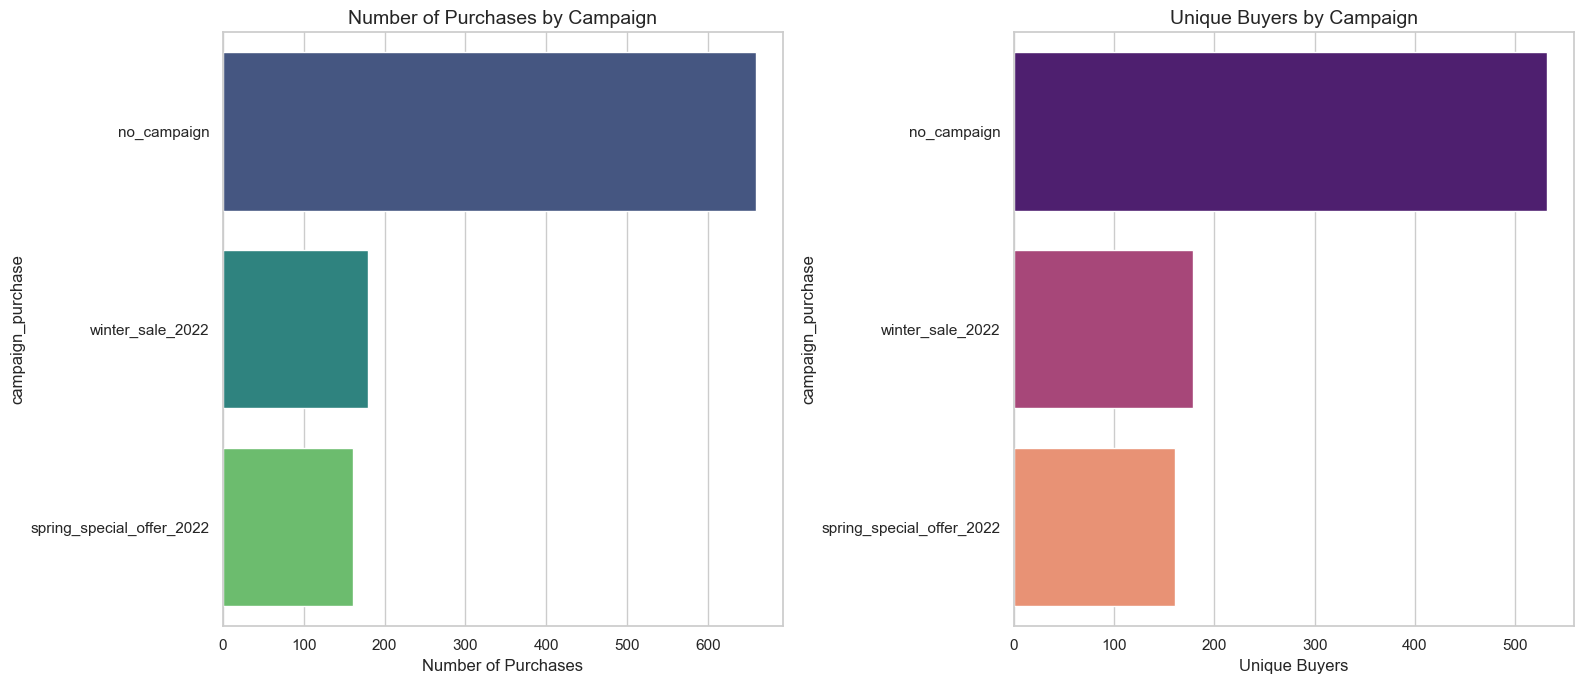

In [13]:
# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart - Number of Purchases by Campaign
sns.barplot(data=campaign_stats, 
            x='num_purchases', 
            y='campaign_purchase', 
            palette='viridis', ax=axes[0])
axes[0].set_title('Number of Purchases by Campaign', fontsize=14)
axes[0].set_xlabel('Number of Purchases')

# Bar chart - Unique Buyers by Campaign
sns.barplot(data=campaign_stats, 
            x='unique_buyers', 
            y='campaign_purchase', 
            palette='magma', ax=axes[1])
axes[1].set_title('Unique Buyers by Campaign', fontsize=14)
axes[1].set_xlabel('Unique Buyers')

plt.tight_layout()
plt.show()

In [14]:
# 3. Key Insights
print("\n" + "="*60)
print("🔍 KEY CAMPAIGN INSIGHTS")
print("="*60)

top_campaign = campaign_stats.iloc[0]
print(f"🏆 Most Successful Campaign : {top_campaign['campaign_purchase']}")
print(f"   • Purchases              : {top_campaign['num_purchases']:,}")
print(f"   • Unique Buyers          : {top_campaign['unique_buyers']:,}")

no_campaign = campaign_stats[campaign_stats['campaign_purchase'] == 'no_campaign'].iloc[0]
print(f"\n📉 No Campaign Period:")
print(f"   • Purchases : {no_campaign['num_purchases']:,}")
print(f"   • Unique Buyers : {no_campaign['unique_buyers']:,}")

print(f"\n📈 Campaign vs Non-Campaign:")
print(f"   Campaigns drove {campaign_stats[campaign_stats['campaign_purchase'] != 'no_campaign']['num_purchases'].sum():,} purchases")


🔍 KEY CAMPAIGN INSIGHTS
🏆 Most Successful Campaign : no_campaign
   • Purchases              : 660
   • Unique Buyers          : 532

📉 No Campaign Period:
   • Purchases : 660
   • Unique Buyers : 532

📈 Campaign vs Non-Campaign:
   Campaigns drove 340 purchases


In [15]:
print("📈 Campaign vs Normal Period Engagement Analysis (Session Count Based)\n")

# Main Query
query = """
WITH engagement_with_period AS (
    SELECT 
        e.*,
        CASE 
            WHEN e.date_engaged BETWEEN '2022-01-17' AND '2022-01-28' THEN 'winter_sale_2022'
            WHEN e.date_engaged BETWEEN '2022-03-21' AND '2022-03-31' THEN 'spring_special_offer_2022'
            WHEN e.date_engaged BETWEEN '2022-05-20' AND '2022-06-01' THEN 'data_science_summer_campaign_2022'
            WHEN e.date_engaged BETWEEN '2022-07-18' AND '2022-07-29' THEN 'most_wanted_campaign'
            WHEN e.date_engaged = '2022-09-16' THEN 'platform_gamification'
            WHEN e.date_engaged BETWEEN '2022-09-19' AND '2022-09-30' THEN 'data_science_hero_campaign'
            ELSE 'normal_period'
        END AS period_type
    FROM student_engagement e
)
SELECT 
    period_type,
    COUNT(*) AS total_engagement_sessions,                    -- Primary metric: count of engagement_id
    COUNT(DISTINCT student_id) AS unique_students_engaged,
    ROUND(AVG(engagement_quizzes), 2) AS avg_quizzes_attempted,
    ROUND(AVG(engagement_exams), 2) AS avg_exams_attempted,
    ROUND(AVG(engagement_lessons), 2) AS avg_lessons_engaged,
    SUM(engagement_quizzes) AS total_quizzes,
    SUM(engagement_exams) AS total_exams,
    SUM(engagement_lessons) AS total_lessons
FROM engagement_with_period
GROUP BY period_type
ORDER BY 
    CASE WHEN period_type = 'normal_period' THEN 1 ELSE 0 END,
    total_engagement_sessions DESC;
"""

engagement_comparison = pd.read_sql(query, conn)

print("✅ Engagement Comparison Results:")
print(engagement_comparison)

📈 Campaign vs Normal Period Engagement Analysis (Session Count Based)

✅ Engagement Comparison Results:
                         period_type  total_engagement_sessions  \
0                   winter_sale_2022                        135   
1  data_science_summer_campaign_2022                         46   
2          spring_special_offer_2022                         17   
3                      normal_period                        802   

   unique_students_engaged  avg_quizzes_attempted  avg_exams_attempted  \
0                       64                   1.00                 0.36   
1                       42                   0.48                 0.39   
2                       11                   1.00                 0.29   
3                      311                   1.00                 0.25   

   avg_lessons_engaged  total_quizzes  total_exams  total_lessons  
0                 1.00            135           49            135  
1                 0.98             22           18   

C:\Users\yvett\AppData\Local\Temp\ipykernel_20556\169502575.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=engagement_comparison,
C:\Users\yvett\AppData\Local\Temp\ipykernel_20556\169502575.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=engagement_comparison,


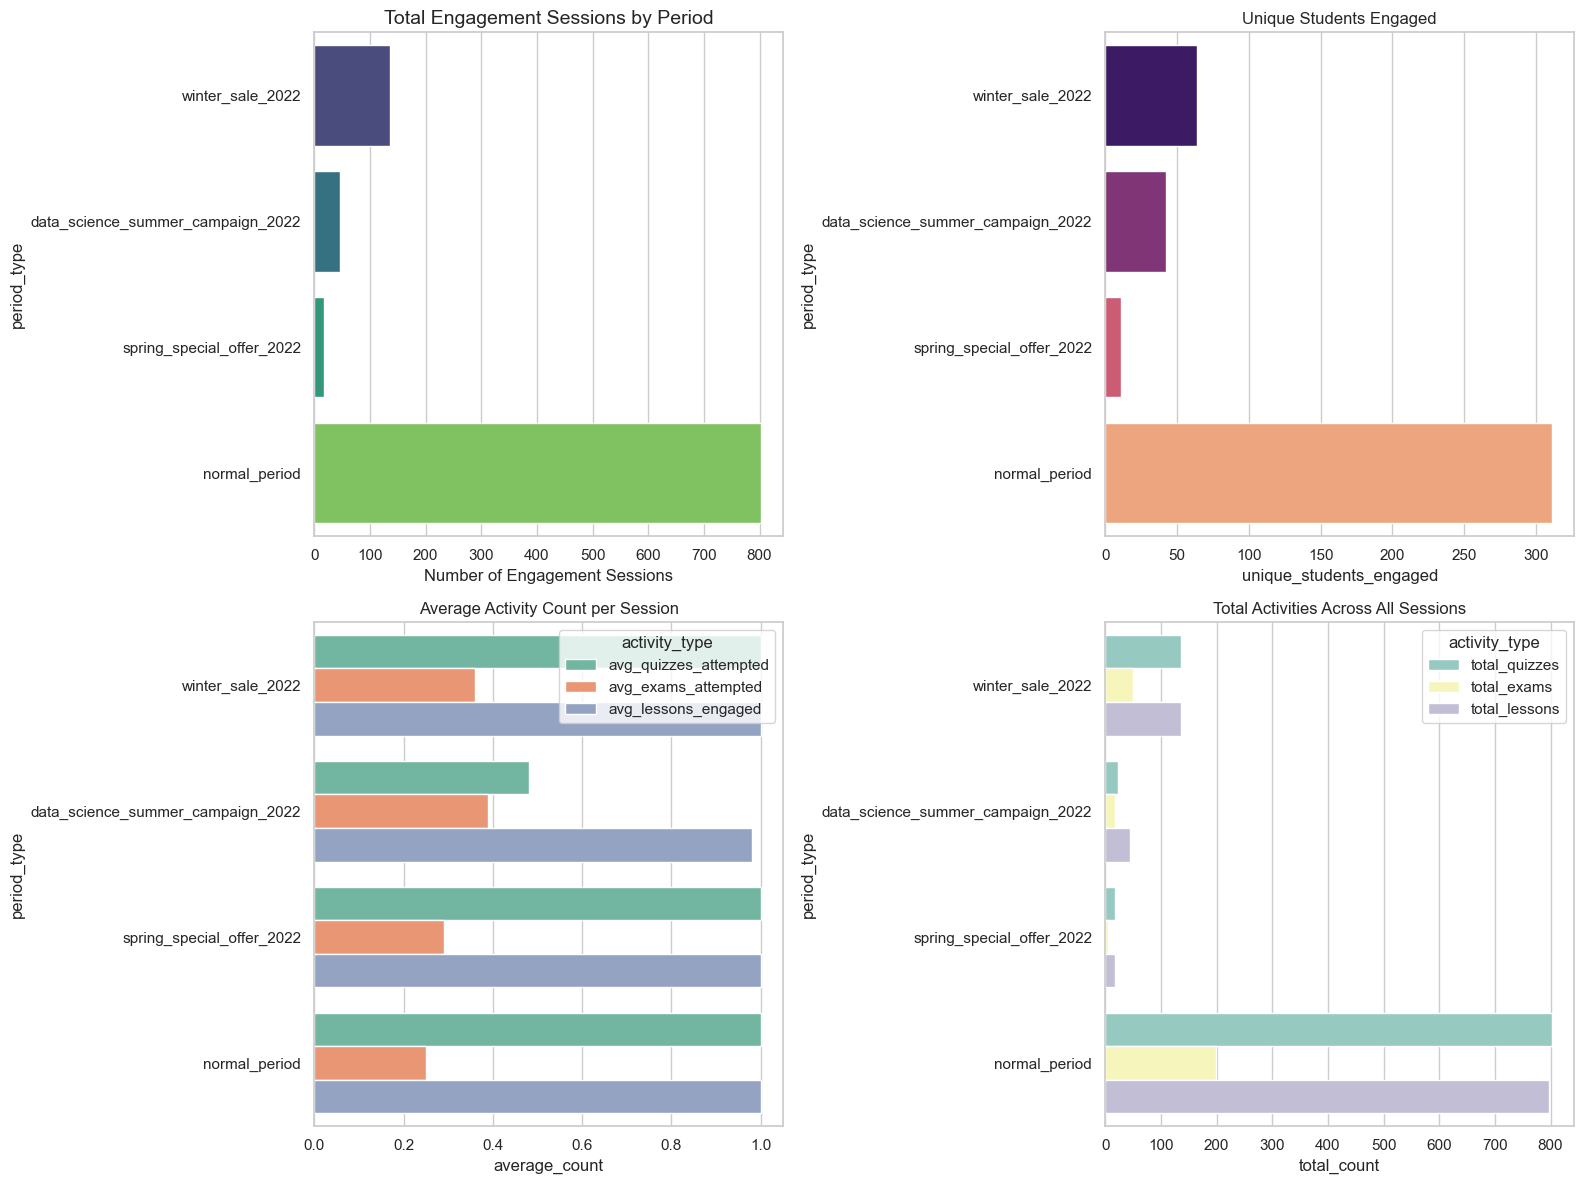

In [16]:
# =============================================
# Visualizations
# =============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total Engagement Sessions (Main Metric)
sns.barplot(data=engagement_comparison, 
            x='total_engagement_sessions', 
            y='period_type', 
            palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Total Engagement Sessions by Period', fontsize=14)
axes[0,0].set_xlabel('Number of Engagement Sessions')

# 2. Unique Students Engaged
sns.barplot(data=engagement_comparison, 
            x='unique_students_engaged', 
            y='period_type', 
            palette='magma', ax=axes[0,1])
axes[0,1].set_title('Unique Students Engaged')

# 3. Average Activity Breakdown
activity_df = engagement_comparison.melt(
    id_vars=['period_type'],
    value_vars=['avg_quizzes_attempted', 'avg_exams_attempted', 'avg_lessons_engaged'],
    var_name='activity_type',
    value_name='average_count'
)

sns.barplot(data=activity_df, 
            x='average_count', 
            y='period_type', 
            hue='activity_type', 
            palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Average Activity Count per Session')

# 4. Total Activities
total_activity = engagement_comparison.melt(
    id_vars=['period_type'],
    value_vars=['total_quizzes', 'total_exams', 'total_lessons'],
    var_name='activity_type',
    value_name='total_count'
)

sns.barplot(data=total_activity, 
            x='total_count', 
            y='period_type', 
            hue='activity_type', 
            palette='Set3', ax=axes[1,1])
axes[1,1].set_title('Total Activities Across All Sessions')

plt.tight_layout()
plt.show()

In [17]:
# =============================================
# Key Insights
# =============================================
print("\n" + "="*70)
print("🔍 KEY INSIGHTS: Campaign Impact on Engagement (Session Count)")
print("="*70)

normal = engagement_comparison[engagement_comparison['period_type'] == 'normal_period'].iloc[0]
campaign_rows = engagement_comparison[engagement_comparison['period_type'] != 'normal_period']

best_campaign = campaign_rows.loc[campaign_rows['total_engagement_sessions'].idxmax()]

print(f"Normal Period:")
print(f"   • Total Sessions          : {normal['total_engagement_sessions']:,}")
print(f"   • Unique Students Engaged : {normal['unique_students_engaged']:,}")

print(f"\nBest Performing Campaign: **{best_campaign['period_type']}**")
print(f"   • Total Sessions          : {best_campaign['total_engagement_sessions']:,}")
print(f"   • Unique Students Engaged : {best_campaign['unique_students_engaged']:,}")

if best_campaign['total_engagement_sessions'] > normal['total_engagement_sessions']:
    print(f"\n✅ Campaigns generated MORE engagement sessions than normal periods!")
else:
    print(f"\n⚠️  Campaigns generated fewer engagement sessions than normal periods.")

print(f"\nTotal engagement sessions during all campaigns combined: {campaign_rows['total_engagement_sessions'].sum():,}")


🔍 KEY INSIGHTS: Campaign Impact on Engagement (Session Count)
Normal Period:
   • Total Sessions          : 802
   • Unique Students Engaged : 311

Best Performing Campaign: **winter_sale_2022**
   • Total Sessions          : 135
   • Unique Students Engaged : 64

⚠️  Campaigns generated fewer engagement sessions than normal periods.

Total engagement sessions during all campaigns combined: 198


**Visualization**: Grouped bar chart showing total engagement sessions by period.

## Phase 3: Combining Tables in SQL (Student Journey Analysis)
### Goal: Compute key platform KPIs and identify high-level issues.

In [18]:
# Add useful indexes (run this once)
with tqdm(total=1, desc="Course Analysis") as pbar:
    print("Creating indexes to speed up future queries...")
    
    conn.execute("CREATE INDEX IF NOT EXISTS idx_learning_course_student ON student_learning(course_id, student_id);")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_engagement_student ON student_engagement(student_id);")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_ratings_course ON course_ratings(course_id);")
    
    conn.commit()
    print("✅ Indexes created!")
    pbar.update(1)

Course Analysis: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.34it/s]

Creating indexes for better performance...
✅ Indexes created!


In [20]:
# =============================================
# PHASE 3: Fixed & Faster Student Journey Analysis
# =============================================

print("🔗 Running Fixed Student Journey Analysis...\n")

with tqdm(total=1, desc="Course Analysis") as pbar:
    query = """
    SELECT 
        c.course_title,
        COUNT(DISTINCT p.student_id) AS total_buyers,
        COUNT(DISTINCT l.student_id) AS started_learning,
        COUNT(DISTINCT e.student_id) AS actively_engaged,
        COUNT(DISTINCT r.student_id) AS gave_rating,
        
        ROUND(100.0 * COUNT(DISTINCT l.student_id) / NULLIF(COUNT(DISTINCT p.student_id), 0), 2) AS learning_start_rate_pct,
        ROUND(100.0 * COUNT(DISTINCT e.student_id) / NULLIF(COUNT(DISTINCT p.student_id), 0), 2) AS engagement_rate_pct,
        ROUND(100.0 * COUNT(DISTINCT r.student_id) / NULLIF(COUNT(DISTINCT p.student_id), 0), 2) AS rating_rate_pct
    FROM course_info c
    LEFT JOIN student_purchases p ON 1 = 1
    LEFT JOIN student_learning l ON c.course_id = l.course_id
    LEFT JOIN student_engagement e ON l.student_id = e.student_id
    LEFT JOIN course_ratings r ON c.course_id = r.course_id
    GROUP BY c.course_title
    ORDER BY engagement_rate_pct ASC NULLS LAST;
    """
    
    journey_df = pd.read_sql(query, conn)
    
    print(f"✅ Analysis completed! ({len(journey_df)} courses)")
    
    print("\nTop 10 Courses with Lowest Engagement Rate:")
    print(journey_df[['course_title', 'total_buyers', 'started_learning', 
                      'actively_engaged', 'engagement_rate_pct']].head(10).round(2))
    
    print(f"\nOverall Average Engagement Rate: {journey_df['engagement_rate_pct'].mean():.2f}%")
    print(f"Lowest Engagement Rate : {journey_df['engagement_rate_pct'].min():.2f}%")
    print(f"Highest Engagement Rate : {journey_df['engagement_rate_pct'].max():.2f}%")
    
    pbar.update(1)

🔗 Running Fixed Student Journey Analysis...



Course Analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [14:28<00:00, 868.44s/it]

✅ Analysis completed! (46 courses)

Top 10 Courses with Lowest Engagement Rate:
                                        course_title  total_buyers  \
0                              A/B Testing in Python           839   
1  Convolutional Neural Networks with TensorFlow ...           839   
2                        Data-Driven Business Growth           839   
3                          Dates and Times in Python           839   
4                     Fashion Analytics with Tableau           839   
5                 Introduction to Business Analytics           839   
6                          Machine Learning in Excel           839   
7  Machine Learning with Decision Trees and Rando...           839   
8          Machine Learning with K-Nearest Neighbors           839   
9                 Machine Learning with NaÃ¯ve Bayes           839   

   started_learning  actively_engaged  engagement_rate_pct  
0                 1                 0                  0.0  
1                 2        

**Opportunity**: Courses with high purchases but low engagement/progress = content or difficulty mismatch.